In [ ]:
import math

def friction_factor_haaland(Re, roughness, diameter):
    """
    Returns the friction factor f using Haaland's Equation:
      1 / sqrt(f) = -1.8 * log10( ( (k/D)/3.7 )^1.11 + 6.9/Re )
    where k is the pipe roughness height.

    For laminar flow (Re < ~2000), we switch to 64/Re as an approximation.
    """
    if Re < 1e-6:
        # Guard against a nearly zero Reynolds number
        return 0.0
    if Re < 2000:
        # Laminar regime
        return 64.0 / Re

    term = ((roughness/diameter)/3.7)**1.11 + (6.9/Re)
    return 1.0 / ( -1.8 * math.log10(term) )**2


def main_equation_residual(v_b, param):
    """
    Computes the residual of the main pressure/energy equation:

      residual(v_b) = (del_p/(rho*g)) - [ del_h
                                          + v_b^2/(2*g)
                                          + 0.5*( ... f_A-based terms ... )*v_b^2
                                          + 0.5*( ... f_B-based terms ... )*v_b^2 ]

    where f_A, f_B are computed from a direct friction correlation.
    """
    # Unpack parameters for readability
    dp   = param['del_p']
    rho  = param['rho']
    g    = param['g']
    delh = param['del_h']
    dA   = param['d_A']
    D = param['D']
    LA   = param['L_A']
    nu   = param['visc']         # kinematic viscosity
    epsA = param['eps_A']        # roughness pipe B

    # Reynolds numbers for each pipe
    ReA = (v_b * dA) / nu

    # Compute friction factors via Haaland (or any direct correlation)
    fA = friction_factor_haaland(ReA, epsA, dA)

    # Right-hand side of your main equation
    # (matches the eq_main structure you provided)
    rhs = (delh
            + (v_b**2)/(2*g)
            + ((1 - (dA**2/D**2))**2
                + 6*0.08 + 2*1.1
                + fA*LA/dA
            )*(v_b**2)/(2*g)
          )

    lhs = dp/(rho*g)   # left-hand side

    return lhs - rhs   # residual = LHS - RHS


def solve_velocity_bisection(param, v_b_low=1e-5, v_b_high=7, tol=1e-6, max_iter=100):
    """
    Solve for v_b by bracket-bisection:
      1) Evaluate residual at v_b_low and v_b_high.
      2) Keep halving the bracket until residual is close to zero
         or we reach max_iter.

    Constraints:
      - main_equation_residual(v_b_low) and main_equation_residual(v_b_high)
        must have opposite signs (one positive, one negative).
    """
    f_low = main_equation_residual(v_b_low, param)
    f_high = main_equation_residual(v_b_high, param)

    if f_low * f_high > 0:
        raise ValueError(
            "Bisection method: The signs of residual at v_b_low and v_b_high must be different.\n"
            f"f_low={f_low}, f_high={f_high}"
        )

    for iteration in range(max_iter):
        v_b_mid = 0.5*(v_b_low + v_b_high)
        f_mid = main_equation_residual(v_b_mid, param)

        if abs(f_mid) < tol:
            # Converged
            return v_b_mid

        # Narrow down bracket based on the sign of the residual
        if (f_low * f_mid) < 0:
            # Root is between v_b_low and v_b_mid
            v_b_high = v_b_mid
            f_high = f_mid
        else:
            # Root is between v_b_mid and v_b_high
            v_b_low = v_b_mid
            f_low = f_mid

    # If we exit the loop, no convergence within max_iter
    raise ValueError("Bisection did not converge within max_iter iterations.")

param_values = {
    'del_p' : 250000,  # Pa
    'rho'   : 1000.0,         # kg/m^3
    'g'     : 0.001,            # m/s^2
    'del_h' : 100e-3,  # m
    'd_A'   : 6.53e-3,
    'D' : 12.7e-3,       # m
    'L_A'   : 100e-3,        # m
    'visc'  : 1.0e-6,         # m^2/s (kinematic viscosity = mu/rho)
    'eps_A' : 1e-6,         # Pipe roughness (m) for A
}
# 1) Choose a bracket for velocity in [0.00001, 5.0] m/s
# 2) Solve using bisection
v_b_solution = solve_velocity_bisection(param_values, v_b_low=1, v_b_high=70)

# Print the final velocity
print(f"Final velocity solution = {v_b_solution:.6f} m/s")
print(f"flow rate: {param_values['rho']*v_b_solution*math.pi*(param_values['d_A']/2)**2}")
print((v_b_solution * param_values['d_A']) / param_values['visc'])
#accumulator nominal volume: 0.25L
#water nominal volume: 0.180L => gas initial volume at 3.5bar = 0.007Lb


Final velocity solution = 10.511490 m/s
flow rate: 0.352030692326482
68640.03038753048


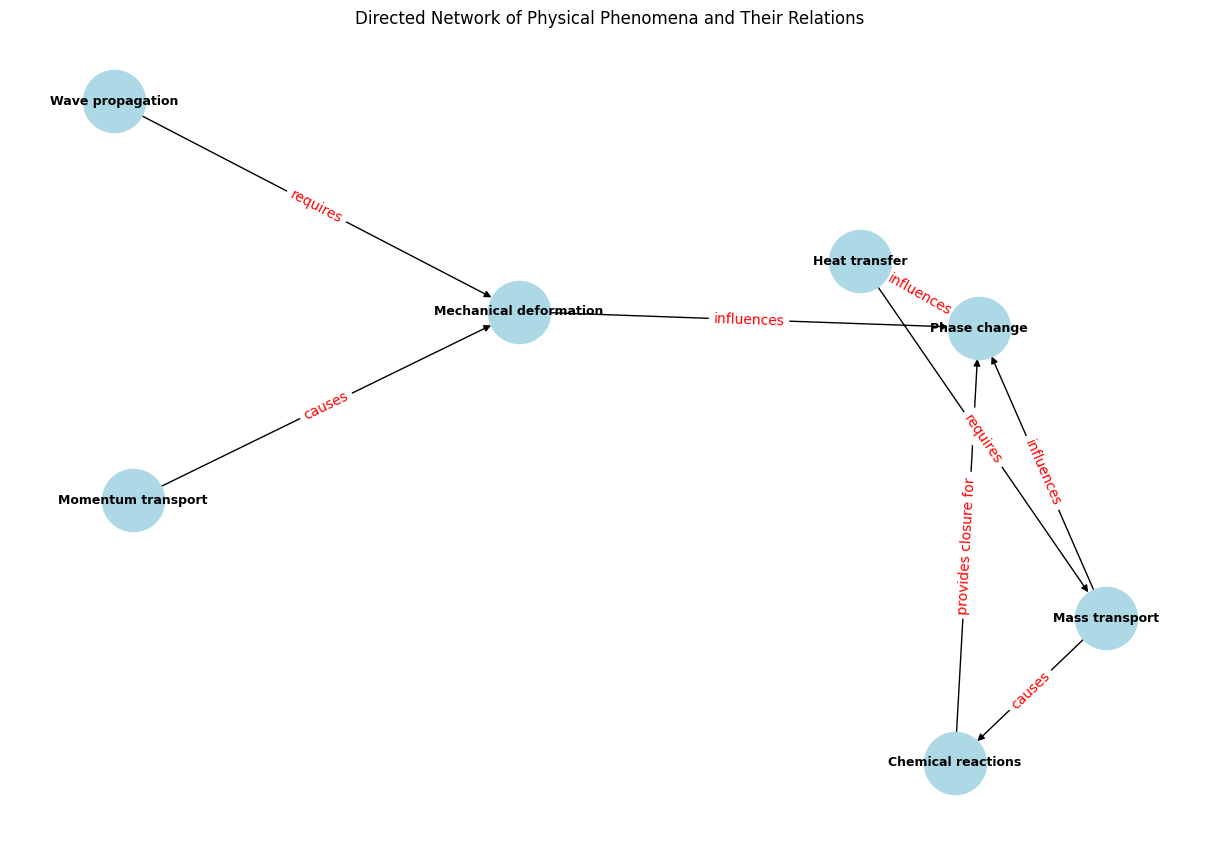

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

# Nodes and edges setup
phenomena = {
    "Heat transfer": ["Physical", "Empirical", "Mathematical", "Computer"],
    "Mass transport": ["Physical", "Empirical", "Mathematical", "Computer"],
    "Momentum transport": ["Physical", "Empirical", "Mathematical", "Computer"],
    "Mechanical deformation": ["Physical", "Empirical", "Mathematical", "Computer"],
    "Phase change": ["Physical", "Empirical", "Mathematical", "Computer"],
    "Wave propagation": ["Physical", "Empirical", "Mathematical", "Computer"],
    "Chemical reactions": ["Physical", "Empirical", "Mathematical", "Computer"],
}

edges = [
    ("Heat transfer", "Phase change", "influences"),
    ("Heat transfer", "Mass transport", "requires"),
    ("Mass transport", "Chemical reactions", "causes"),
    ("Mass transport", "Phase change", "influences"),
    ("Momentum transport", "Mechanical deformation", "causes"),
    ("Mechanical deformation", "Phase change", "influences"),
    ("Wave propagation", "Mechanical deformation", "requires"),
    ("Chemical reactions", "Phase change", "provides closure for"),
]

G = nx.DiGraph()
for p, labels in phenomena.items():
    G.add_node(p, approaches=", ".join(labels))
for src, dst, rel in edges:
    G.add_edge(src, dst, relation=rel)

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=9, font_weight="bold")
edge_labels = {(u, v): G[u][v]['relation'] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title("Directed Network of Physical Phenomena and Their Relations")
plt.axis('off')
plt.show()


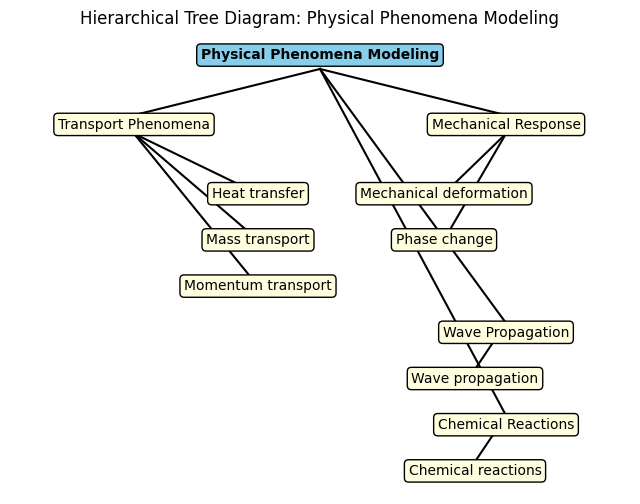

In [3]:
import matplotlib.pyplot as plt

def plot_tree_diagram():
    fig, ax = plt.subplots(figsize=(8,6))
    ax.axis('off')

    # Main branches and leaves manually positioned
    points = [
        (0.5, 0.95, "Physical Phenomena Modeling", "root"),
        (0.2, 0.8, "Transport Phenomena", "branch"),
        (0.4, 0.65, "Heat transfer", "leaf"),
        (0.4, 0.55, "Mass transport", "leaf"),
        (0.4, 0.45, "Momentum transport", "leaf"),
        (0.8, 0.8, "Mechanical Response", "branch"),
        (0.7, 0.65, "Mechanical deformation", "leaf"),
        (0.7, 0.55, "Phase change", "leaf"),
        (0.8, 0.35, "Wave Propagation", "branch"),
        (0.75, 0.25, "Wave propagation", "leaf"),
        (0.8, 0.15, "Chemical Reactions", "branch"),
        (0.75, 0.05, "Chemical reactions", "leaf")
    ]
    for x, y, label, kind in points:
        ax.text(x, y, label, fontsize=10, fontweight='bold' if kind == 'root' else 'normal',
                ha='center', va='center', bbox=dict(boxstyle='round,pad=0.3', fc='skyblue' if kind == 'root' else 'lightyellow'))

    # Draw links (edges)
    ax.plot([0.5, 0.2], [0.92, 0.82], 'k-')
    ax.plot([0.5, 0.8], [0.92, 0.82], 'k-')
    # Transport branches
    for y in [0.65, 0.55, 0.45]:
        ax.plot([0.2, 0.4], [0.78, y], 'k-')
    # Mechanical Response
    ax.plot([0.8, 0.7], [0.78, 0.65], 'k-')
    ax.plot([0.8, 0.7], [0.78, 0.55], 'k-')
    # Wave Propagation
    ax.plot([0.5, 0.8], [0.92, 0.37], 'k-')
    ax.plot([0.8, 0.75], [0.37, 0.27], 'k-')
    # Chemical Reactions
    ax.plot([0.5, 0.8], [0.92, 0.17], 'k-')
    ax.plot([0.8, 0.75], [0.17, 0.07], 'k-')

    plt.title('Hierarchical Tree Diagram: Physical Phenomena Modeling')
    plt.ylim(0, 1)
    plt.xlim(0, 1)
    plt.show()

plot_tree_diagram()
